**Формируем из csv необходимый датасет:**

In [ ]:
import pandas as pd
import numpy as np
import time
import requests
import re

#dataset = pd.read_excel('Реестр (1).xlsx')
dataset = pd.read_csv('reestr.csv', sep=';', header=2)

dataset.columns = dataset.columns.str.strip()

companies = dataset[
    dataset["Категория"].isin(["Малое предприятие","Среднее предприятие"])
    & dataset["Основной вид деятельности"].eq("41.20 Строительство жилых и нежилых зданий")
    & dataset["Тип субъекта"].eq("Юридическое лицо")
    & dataset["ИНН"].notna()].copy()

companies["ИНН"] = (
    companies["ИНН"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)
    .str.zfill(10)
)

companies = companies.drop_duplicates(subset=["ИНН"])

SEARCH_URL = (
    "https://bo.nalog.gov.ru"
    "/advanced-search/organizations/search"
)

session = requests.Session()

session.headers.update({
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/126.0.0.0 Safari/537.36"
    ),
    "Accept": "application/json, text/plain, */*",
    "Referer": "https://bo.nalog.gov.ru/",
})


def normalize_inn(value):
    if value is None or pd.isna(value):
        return None

    inn = re.sub(r"\D", "", str(value))

    if len(inn) not in (10, 12):
        return None

    return inn


def get_org_id(inn):
    inn = normalize_inn(inn)

    if inn is None:
        return {
            "ИНН": None,
            "org_id": None,
            "status": "invalid_inn"
        }

    try:
        response = session.get(
            SEARCH_URL,
            params={
                "query": inn,
                "page": 0
            },
            timeout=30
        )

        response.raise_for_status()
        data = response.json()

    except requests.Timeout:
        return {
            "ИНН": inn,
            "org_id": None,
            "status": "timeout"
        }

    except requests.RequestException as error:
        return {
            "ИНН": inn,
            "org_id": None,
            "status": f"request_error: {error}"
        }

    except ValueError:
        return {
            "ИНН": inn,
            "org_id": None,
            "status": "invalid_json"
        }

    content = data.get("content")

    if content is None:
        return {
            "ИНН": inn,
            "org_id": None,
            "status": "content_missing"
        }

    if len(content) == 0:
        return {
            "ИНН": inn,
            "org_id": None,
            "status": "not_found"
        }

    for organization in content:
        response_inn = normalize_inn(
            organization.get("inn")
        )

        if response_inn == inn:
            return {
                "ИНН": inn,
                "org_id": organization.get("id"),
                "status": "ok"
            }

    return {
        "ИНН": inn,
        "org_id": None,
        "status": "no_exact_match"
    }

unique_inns = (
    companies["ИНН"]
    .dropna()
    .apply(normalize_inn)
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)

results = []

for number, inn in enumerate(unique_inns, start=1):
    parsed = get_org_id(inn)
    results.append(parsed)

    print(
        f"{number}/{len(unique_inns)} "
        f"ИНН={inn} "
        f"org_id={parsed['org_id']} "
        f"status={parsed['status']}"
    )

    time.sleep(0.3)

org_ids = pd.DataFrame(results)

org_ids.head()

companies["ИНН"] = companies["ИНН"].apply(normalize_inn)

companies = companies.merge(
    org_ids,
    on="ИНН",
    how="left"
)

companies.to_csv(
    "companies_with_org_id.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

companies["org_id"] = pd.to_numeric(
    companies["org_id"],
    errors="coerce"
).astype("Int64")

print(companies["status"].value_counts(dropna=False))
print("Всего компаний:", len(companies))
print("Найден org_id:", companies["org_id"].notna().sum())

**Парсим и добавляем к датасету необходимые для EBIT данные:**

In [ ]:
companies = pd.read_csv(
    "companies_with_org_id.csv",
    sep=";",
    dtype={
        "ИНН": str
    }
)

companies.columns = companies.columns.str.strip()

companies["ИНН"] = (
    companies["ИНН"]
    .astype("string")
    .str.replace(r"\D", "", regex=True)
)

companies["org_id"] = pd.to_numeric(
    companies["org_id"],
    errors="coerce"
).astype("Int64")

test_company = companies.loc[
    companies["status"].eq("ok")
    & companies["org_id"].notna()
].iloc[0]

test_inn = test_company["ИНН"]
test_org_id = int(test_company["org_id"])

print("Компания:", test_company["Наименование / ФИО"])
print("ИНН:", test_inn)
print("org_id:", test_org_id)

session = requests.Session()

session.headers.update({
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/126.0.0.0 Safari/537.36"
    ),
    "Accept": "application/json, text/plain, */*",
    "Referer": "https://bo.nalog.gov.ru/",
})

test_url = (
    f"https://bo.nalog.gov.ru/"
    f"nbo/organizations/{test_org_id}/bfo/"
)

response = session.get(
    test_url,
    timeout=30
)

print("HTTP:", response.status_code)
print("Content-Type:", response.headers.get("Content-Type"))
print("URL:", response.url)
print(response.text[:3000])

response.raise_for_status()

test_bfo = response.json()

print("Тип ответа:", type(test_bfo))

if isinstance(test_bfo, list):
    print("Количество элементов:", len(test_bfo))

    if test_bfo:
        print(
            json.dumps(
                test_bfo[0],
                ensure_ascii=False,
                indent=2
            )[:20000]
        )
else:
    print(
        json.dumps(
            test_bfo,
            ensure_ascii=False,
            indent=2
        )[:20000]
    )

**Считаем EBIT и сохраняем в отдельный csv:**

In [ ]:
def get_annual_correction(report):
    corrections = []

    for item in report.get("typeCorrections") or []:
        correction = item.get("correction")

        if not isinstance(correction, dict):
            continue

        if not isinstance(
            correction.get("financialResult"),
            dict
        ):
            continue

        if (
            item.get("type") == 12
            or correction.get("periodType") == 12
        ):
            corrections.append(correction)

    if not corrections:
        return None

    return max(
        corrections,
        key=lambda x: (
            x.get("correctionVersion", -1),
            x.get("datePresent", "")
        )
    )


def to_number(value):
    if value is None:
        return np.nan

    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


financial_rows = []
error_rows = []

eligible_companies = (
    companies.loc[
        companies["status"].eq("ok")
        & companies["org_id"].notna(),
        [
            "Наименование / ФИО",
            "ИНН",
            "org_id"
        ]
    ]
    .drop_duplicates(subset=["org_id"])
    .reset_index(drop=True)
)

total = len(eligible_companies)

for number, row in eligible_companies.iterrows():
    company_name = row["Наименование / ФИО"]
    inn = row["ИНН"]
    org_id = int(row["org_id"])

    url = (
        f"https://bo.nalog.gov.ru/"
        f"nbo/organizations/{org_id}/bfo/"
    )

    try:
        response = session.get(
            url,
            timeout=60
        )

        response.raise_for_status()
        reports = response.json()

    except Exception as error:
        error_rows.append({
            "Наименование": company_name,
            "ИНН": inn,
            "org_id": org_id,
            "error": str(error)
        })

        print(
            f"{number + 1}/{total} "
            f"ИНН={inn} "
            f"status=error"
        )

        time.sleep(0.3)
        continue

    if not isinstance(reports, list):
        error_rows.append({
            "Наименование": company_name,
            "ИНН": inn,
            "org_id": org_id,
            "error": "Ответ не является списком"
        })

        continue

    for report in reports:
        if not isinstance(report, dict):
            continue

        year = report.get("period")
        correction = get_annual_correction(report)

        result = {
            "Наименование": company_name,
            "ИНН": inn,
            "org_id": org_id,
            "year": year,
            "EBIT": np.nan,
            "net_profit": np.nan,
            "status": None
        }

        if correction is None:
            result["status"] = (
                "annual_correction_not_found"
            )

            financial_rows.append(result)
            continue

        financial_result = correction.get(
            "financialResult"
        )

        if not isinstance(financial_result, dict):
            result["status"] = (
                "financial_result_not_found"
            )

            financial_rows.append(result)
            continue

        line_2400 = to_number(
            financial_result.get("current2400")
        )

        if not pd.isna(line_2400):
            result["net_profit"] = line_2400 * 1000

        knd = (
            correction.get("knd")
            or report.get("knd")
        )

        line_2300 = to_number(
            financial_result.get("current2300")
        )

        if pd.isna(line_2300):
            result["status"] = "line_2300_missing"
            financial_rows.append(result)
            continue

        if "current2330" in financial_result:
            line_2330 = to_number(
                financial_result.get("current2330")
            )

            if pd.isna(line_2330):
                line_2330 = 0.0

        elif knd == "0710099":
            line_2330 = 0.0

        else:
            result["status"] = (
                "line_2330_not_disclosed"
            )

            financial_rows.append(result)
            continue

        # Значения БФО передаются в тысячах рублей.
        # Умножаем на 1000 и получаем EBIT в рублях.
        result["EBIT"] = (
            line_2300
            + abs(line_2330)
        ) * 1000

        result["status"] = "calculated"

        financial_rows.append(result)

    print(
        f"{number + 1}/{total} "
        f"ИНН={inn} "
        f"отчетов={len(reports)}"
    )

    if (number + 1) % 100 == 0:
        pd.DataFrame(
            financial_rows
        ).to_csv(
            "company_financials_progress.csv",
            sep=";",
            index=False,
            encoding="utf-8-sig"
        )

        pd.DataFrame(
            error_rows
        ).to_csv(
            "company_financials_errors.csv",
            sep=";",
            index=False,
            encoding="utf-8-sig"
        )

    time.sleep(0.3)


financials = pd.DataFrame(financial_rows)

financials["year"] = pd.to_numeric(
    financials["year"],
    errors="coerce"
).astype("Int64")

financials["EBIT"] = pd.to_numeric(
    financials["EBIT"],
    errors="coerce"
)

financials = (
    financials
    .sort_values([
        "ИНН",
        "year"
    ])
    .drop_duplicates(
        subset=[
            "ИНН",
            "year"
        ],
        keep="last"
    )
    .reset_index(drop=True)
)

financials.to_csv(
    "company_financials.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)


reports_by_year = (
    financials.loc[
        financials["year"].notna()
    ]
    .groupby(
        "year",
        as_index=False
    )
    .agg(
        **{
            "companies with report": (
                "ИНН",
                "nunique"
            )
        }
    )
)


calculated_by_year = (
    financials.loc[
        financials["status"].eq("calculated")
        & financials["EBIT"].notna()
    ]
    .groupby(
        "year",
        as_index=False
    )
    .agg(
        **{
            "companies with calculation": (
                "ИНН",
                "nunique"
            ),
            "EBIT": (
                "EBIT",
                lambda values: values.sum(
                    min_count=1
                )
            )
        }
    )
)


ebit_by_year = (
    reports_by_year
    .merge(
        calculated_by_year,
        on="year",
        how="left"
    )
    .sort_values("year")
    .reset_index(drop=True)
)

ebit_by_year[
    "companies with calculation"
] = (
    ebit_by_year[
        "companies with calculation"
    ]
    .fillna(0)
    .astype(int)
)

ebit_by_year = ebit_by_year[
    [
        "year",
        "companies with report",
        "companies with calculation",
        "EBIT"
    ]
]

ebit_by_year.to_csv(
    "ebit_by_year.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)


def format_rubles(value):
    if pd.isna(value):
        return ""

    return (
        f"{value:,.0f} ₽"
        .replace(",", " ")
    )


display(
    ebit_by_year.style.format({
        "year": "{:.0f}",
        "companies with report": "{:,.0f}",
        "companies with calculation": "{:,.0f}",
        "EBIT": format_rubles
    })
)

print(
    financials["status"]
    .value_counts(dropna=False)
)

print(
    "Ошибок загрузки:",
    len(error_rows)
)

**Строим графики:**

Доступные годы: 2021, 2022, 2023, 2024, 2025


Введите количество лет N:  3



2024 относительно 2021
Компаний с данными за оба года: 7329
Компаний в расчёте: 6199
Исключено из расчёта из-за нулевой или отрицательной базы: 1130
Минимальный рассчитанный рост: -3 506 838%
Максимальный рассчитанный рост: 10 112 100%
Диапазон, отображённый на графике: от -3464% до 12824%
Крайних наблюдений вне графика: 248


,profit_growth_percent,companies_count
0,-100,250
1,-99,87
2,-98,66
3,-96,52
4,-95,47
5,-97,42
6,-93,41
7,-92,41
8,-86,38
9,-84,38


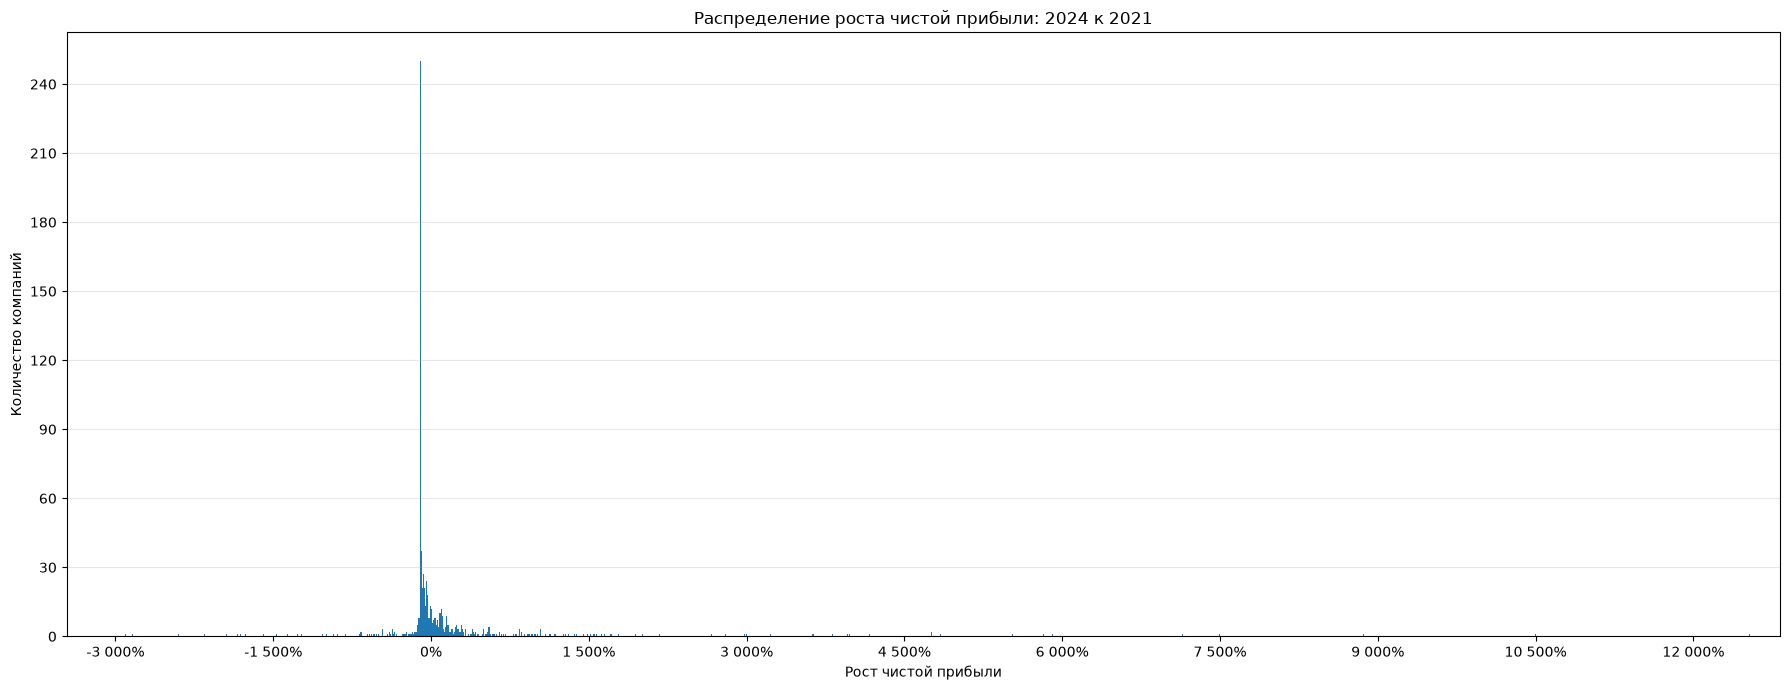


2025 относительно 2022
Компаний с данными за оба года: 7044
Компаний в расчёте: 5852
Исключено из расчёта из-за нулевой или отрицательной базы: 1192
Минимальный рассчитанный рост: -11 552 667%
Максимальный рассчитанный рост: 1 301 000%
Диапазон, отображённый на графике: от -5570% до 6511%
Крайних наблюдений вне графика: 234


,profit_growth_percent,companies_count
0,-100,282
1,-99,92
2,-98,68
3,-97,52
4,-96,52
5,-93,48
6,-89,43
7,-94,41
8,-95,38
9,-92,37


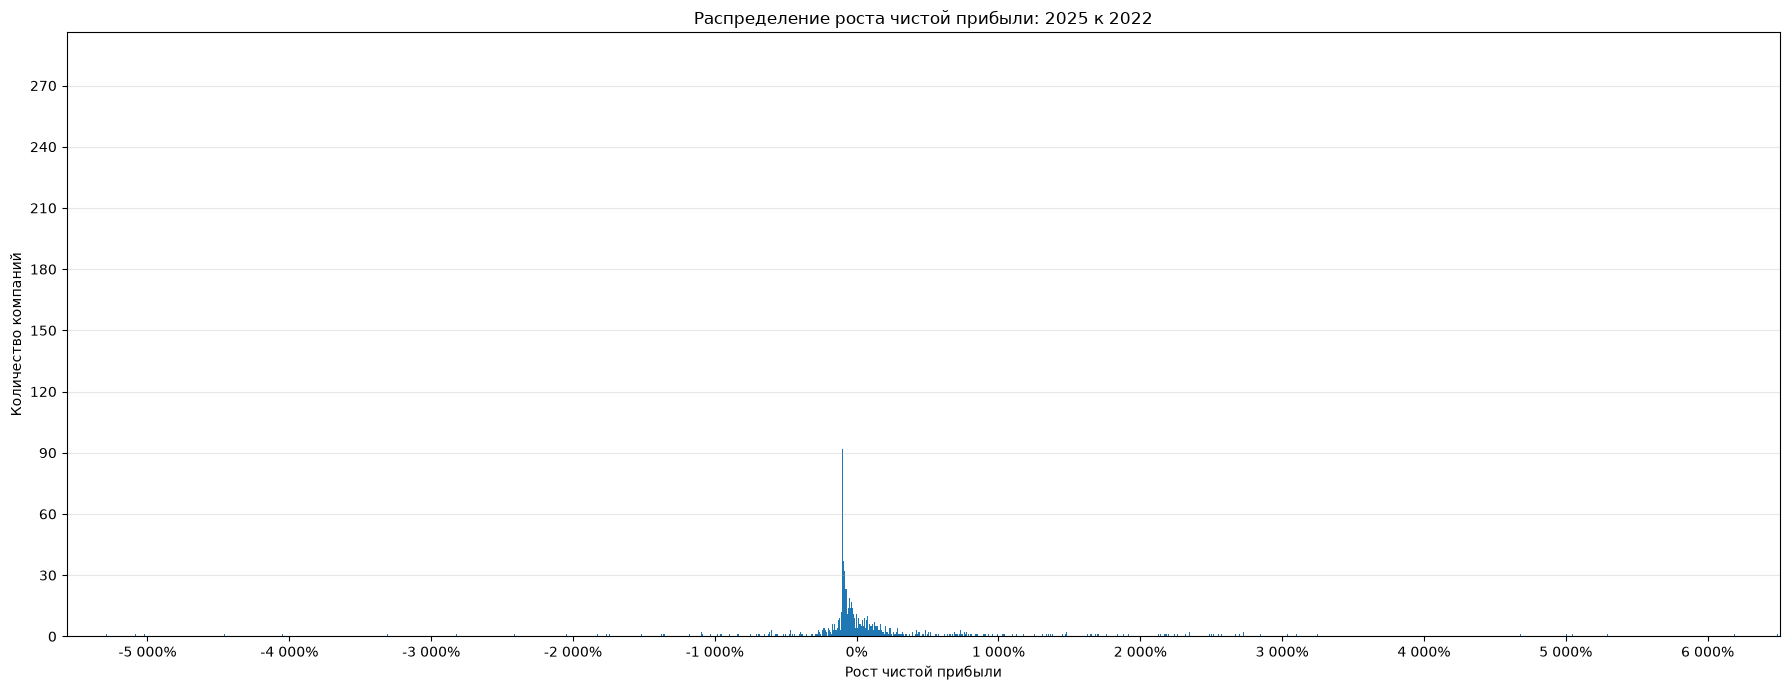

In [9]:
import matplotlib.pyplot as plt

from matplotlib.ticker import (
    FuncFormatter,
    MaxNLocator
)


if "net_profit" not in financials.columns:
    raise KeyError(
        "В financials отсутствует net_profit. "
        "Нужно сначала загрузить current2400."
    )


profit_data = financials[
    [
        "ИНН",
        "year",
        "net_profit"
    ]
].copy()


profit_data["year"] = pd.to_numeric(
    profit_data["year"],
    errors="coerce"
).astype("Int64")


profit_data["net_profit"] = pd.to_numeric(
    profit_data["net_profit"],
    errors="coerce"
)


profit_data = (
    profit_data
    .dropna(
        subset=[
            "ИНН",
            "year",
            "net_profit"
        ]
    )
    .drop_duplicates(
        subset=[
            "ИНН",
            "year"
        ],
        keep="last"
    )
)


available_years = sorted(
    profit_data["year"]
    .astype(int)
    .unique()
)


print(
    "Доступные годы:",
    ", ".join(
        map(str, available_years)
    )
)


try:
    N = int(
        input(
            "Введите количество лет N: "
        )
    )
except ValueError:
    raise ValueError(
        "N должно быть целым числом"
    )


if N <= 0:
    raise ValueError(
        "N должно быть больше нуля"
    )


year_pairs = [
    (
        base_year,
        base_year + N
    )
    for base_year in available_years
    if base_year + N in available_years
]


if not year_pairs:
    print(
        f"График для N={N} построить нельзя."
    )

    print(
        "Нет двух доступных лет "
        f"с разницей {N}."
    )

else:
    for base_year, current_year in year_pairs:
        base_data = (
            profit_data.loc[
                profit_data["year"].eq(
                    base_year
                ),
                [
                    "ИНН",
                    "net_profit"
                ]
            ]
            .rename(
                columns={
                    "net_profit":
                        "base_net_profit"
                }
            )
        )


        current_data = (
            profit_data.loc[
                profit_data["year"].eq(
                    current_year
                ),
                [
                    "ИНН",
                    "net_profit"
                ]
            ]
            .rename(
                columns={
                    "net_profit":
                        "current_net_profit"
                }
            )
        )


        comparison = base_data.merge(
            current_data,
            on="ИНН",
            how="inner"
        )


        companies_with_both_years = len(
            comparison
        )


        # Процентный рост корректно считается
        # только при положительной базе.
        valid_comparison = comparison.loc[
            comparison[
                "base_net_profit"
            ] > 0
        ].copy()


        excluded_base = (
            companies_with_both_years
            - len(valid_comparison)
        )


        if valid_comparison.empty:
            print()
            print(
                f"{current_year} относительно "
                f"{base_year}: нет данных "
                f"для расчёта."
            )

            continue


        valid_comparison[
            "profit_growth_percent_raw"
        ] = (
            (
                valid_comparison[
                    "current_net_profit"
                ]
                /
                valid_comparison[
                    "base_net_profit"
                ]
            )
            - 1
        ) * 100


        # Удаляем бесконечности и технические ошибки.
        valid_comparison = valid_comparison.replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        ).dropna(
            subset=[
                "profit_growth_percent_raw"
            ]
        )


        # X — целый процент.
        valid_comparison[
            "profit_growth_percent"
        ] = (
            valid_comparison[
                "profit_growth_percent_raw"
            ]
            .round()
            .astype("int64")
        )


        # Полное распределение без обрезки.
        full_distribution = (
            valid_comparison[
                "profit_growth_percent"
            ]
            .value_counts()
            .sort_index()
            .rename_axis(
                "profit_growth_percent"
            )
            .reset_index(
                name="companies_count"
            )
        )


        full_distribution.to_csv(
            (
                f"net_profit_growth_"
                f"{current_year}_vs_"
                f"{base_year}.csv"
            ),
            sep=";",
            index=False,
            encoding="utf-8-sig"
        )


        # Границы для читаемого графика.
        # Отбрасываются только крайние 2%
        # с каждой стороны.
        lower_bound = int(
            np.floor(
                valid_comparison[
                    "profit_growth_percent"
                ].quantile(0.02)
            )
        )

        upper_bound = int(
            np.ceil(
                valid_comparison[
                    "profit_growth_percent"
                ].quantile(0.98)
            )
        )


        # Защита от ситуации, когда
        # границы совпали.
        if lower_bound == upper_bound:
            lower_bound -= 1
            upper_bound += 1


        chart_distribution = (
            full_distribution.loc[
                full_distribution[
                    "profit_growth_percent"
                ].between(
                    lower_bound,
                    upper_bound
                )
            ]
            .copy()
        )


        companies_on_chart = (
            valid_comparison[
                "profit_growth_percent"
            ]
            .between(
                lower_bound,
                upper_bound
            )
            .sum()
        )


        excluded_outliers = (
            len(valid_comparison)
            - companies_on_chart
        )


        print()
        print(
            f"{current_year} относительно "
            f"{base_year}"
        )

        print(
            "Компаний с данными за оба года:",
            companies_with_both_years
        )

        print(
            "Компаний в расчёте:",
            len(valid_comparison)
        )

        print(
            "Исключено из расчёта из-за "
            "нулевой или отрицательной базы:",
            excluded_base
        )

        print(
            "Минимальный рассчитанный рост:",
            (
                f"{valid_comparison['profit_growth_percent'].min():,}%"
                .replace(",", " ")
            )
        )

        print(
            "Максимальный рассчитанный рост:",
            (
                f"{valid_comparison['profit_growth_percent'].max():,}%"
                .replace(",", " ")
            )
        )

        print(
            "Диапазон, отображённый на графике:",
            f"от {lower_bound}% "
            f"до {upper_bound}%"
        )

        print(
            "Крайних наблюдений вне графика:",
            excluded_outliers
        )


        # Выводим только наиболее частые проценты,
        # а не таблицу из нескольких тысяч строк.
        most_common = (
            full_distribution
            .sort_values(
                [
                    "companies_count",
                    "profit_growth_percent"
                ],
                ascending=[
                    False,
                    True
                ]
            )
            .head(20)
            .reset_index(drop=True)
        )

        display(most_common)


        figure, axis = plt.subplots(
            figsize=(
                18,
                7
            )
        )


        axis.bar(
            chart_distribution[
                "profit_growth_percent"
            ],
            chart_distribution[
                "companies_count"
            ],
            width=1
        )


        axis.set_title(
            (
                "Распределение роста "
                "чистой прибыли: "
                f"{current_year} к "
                f"{base_year}"
            )
        )


        axis.set_xlabel(
            "Рост чистой прибыли"
        )


        axis.set_ylabel(
            "Количество компаний"
        )


        axis.set_xlim(
            lower_bound,
            upper_bound
        )


        axis.xaxis.set_major_locator(
            MaxNLocator(
                integer=True,
                nbins=15
            )
        )


        axis.yaxis.set_major_locator(
            MaxNLocator(
                integer=True
            )
        )


        axis.xaxis.set_major_formatter(
            FuncFormatter(
                lambda value, position:
                    (
                        f"{value:,.0f}%"
                        .replace(",", " ")
                    )
            )
        )


        axis.grid(
            axis="y",
            alpha=0.3
        )


        plt.tight_layout()
        plt.show()

**Вывод по графикам:**<br>
Огромный "всплеск" левее 0% отражается везде, после него также идёт небольшой отрицательный хвост. Многие компании ушли в убыток, либо в ноль.<br>
Также на всех графиках виден более уверенный положительный хвост - это те компании, что получают прибыль. Причём некоторые аномально многократную, что может указывать на их скромную базовую прибыль.<br>
Большая часть компаний движется умеренно, показывая адекватный уровень прибыльности. Всплеск у нуля со временем уменьшается. Сфера имеет долгий период окупаемости.

**Рисуем карту с топ500 компаний по прибыльности:**

Период: 2021–2025
Годы: [2021, 2022, 2023, 2024, 2025]
1/8841 ИНН=5038038838 лет=5 status=ok
2/8841 ИНН=5027006369 лет=5 status=ok
3/8841 ИНН=1414006922 лет=5 status=ok
4/8841 ИНН=3327332190 лет=5 status=ok
5/8841 ИНН=7816061297 лет=5 status=ok
6/8841 ИНН=3525048992 лет=5 status=ok
7/8841 ИНН=3101000612 лет=5 status=ok
8/8841 ИНН=5902126804 лет=5 status=ok
9/8841 ИНН=0523005733 лет=5 status=ok
10/8841 ИНН=7724745755 лет=5 status=ok
11/8841 ИНН=0504007693 лет=5 status=ok
12/8841 ИНН=2901030646 лет=5 status=ok
13/8841 ИНН=7709008852 лет=5 status=ok
14/8841 ИНН=3811167535 лет=5 status=ok
15/8841 ИНН=7810255553 лет=5 status=ok
16/8841 ИНН=1011005108 лет=5 status=ok
17/8841 ИНН=2310111297 лет=5 status=ok
18/8841 ИНН=3250057750 лет=5 status=ok
19/8841 ИНН=7703595570 лет=5 status=ok
20/8841 ИНН=7813059155 status=incomplete_period missing=[2021, 2022, 2023, 2024, 2025]
21/8841 ИНН=7743373485 status=incomplete_period missing=[2021]
22/8841 ИНН=3328412522 лет=5 status=ok
23/8841 ИНН=7728135831 s

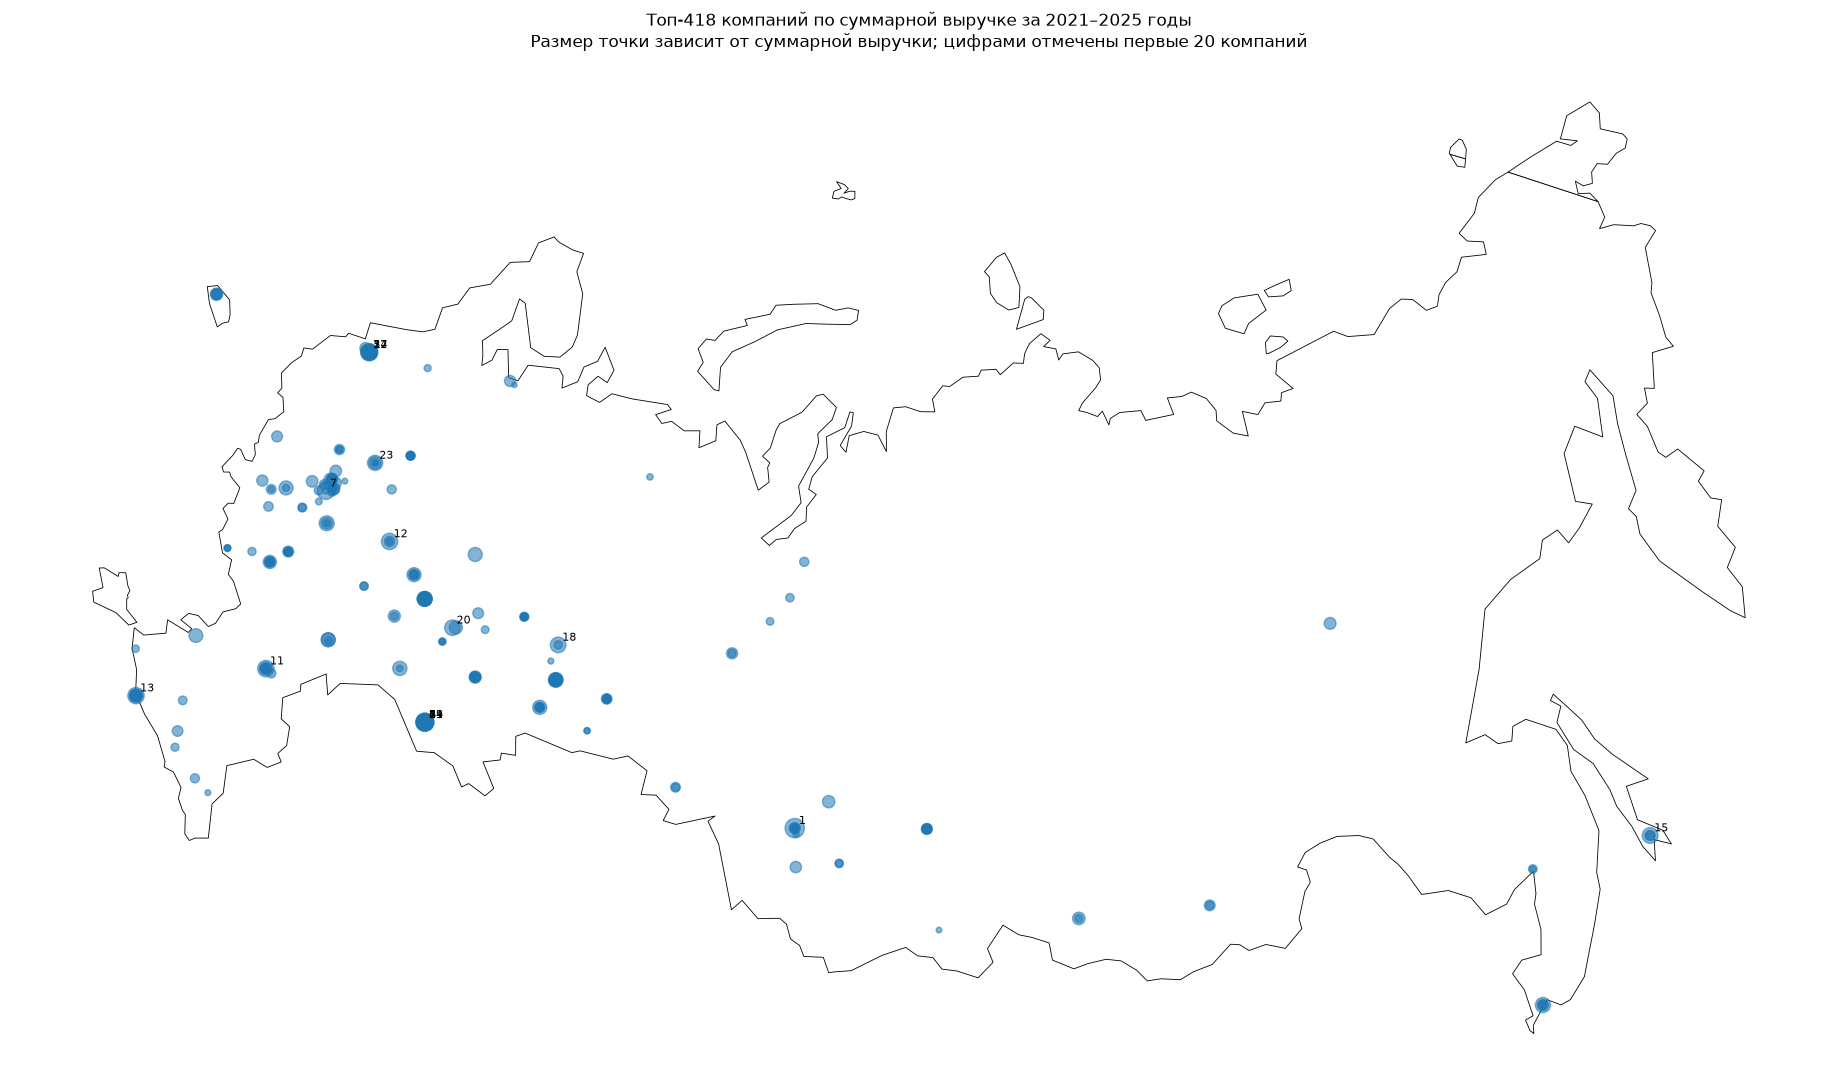

,rank,Наименование,ИНН,revenue,average_annual_revenue,bfo_address,geocode_status,geocode_precision
0,1,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ПРОМСТРОЙМОНТАЖ""",5401304044,34 085 054 000 ₽,6 817 010 800 ₽,"630008, Новосибирская обл, г.о. город Новосибирск, г Новосибирск, ул Кирова, д. 113, кв. оф.329/12,",ok,settlement
1,2,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЭРБЕК""",7702681515,26 708 282 000 ₽,5 341 656 400 ₽,"111250, Москва г, вн.тер.г. муниципальный округ Лефортово, ул Крузенштерна, д. 12, кор. 1, 2н,",ok,settlement
2,3,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ОРГ-РЕСУРСЫ""",4004021545,25 192 693 000 ₽,5 038 538 600 ₽,"249832, Калужская область, р-н Дзержинский, г. Кондрово, ул Комсомольская, д. 11А",not_found,None
3,4,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""КРАСНЫЙ ОКТЯБРЬ - РАССКАЗОВКА""",7718894438,24 662 557 000 ₽,4 932 511 400 ₽,"108814, Город Москва, вн.тер.г. муниципальный округ Коммунарка, ш. Калужское, км 24-й, д. 1, стр. 1, этаж 6, помещ. XIII, ком. 25, офис 619/1",ok,settlement
4,5,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГАЗСТРОЙТЕХ""",7728838739,22 735 602 000 ₽,4 547 120 400 ₽,"194044, Город Санкт-Петербург, вн.тер. г. Муниципальный Округ Сампсониевское, пр-кт Большой Сампсониевский, дом 66А, строение 1, помещение 13-Н, офис 6",ok,settlement
5,6,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СПК-ИНЖИНИРИНГ""",7705989107,22 038 042 000 ₽,4 407 608 400 ₽,"129515, Город Москва, ул. Академика Королева, дом 13, строение 1, этаж 6, помещение V, комната 32",ok,settlement
6,7,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ВИК""",7723906368,21 499 636 000 ₽,4 299 927 200 ₽,"142000, Московская обл, Домодедово г, Северный мкр., Каширское шоссе, строение 17А, офис 9",ok,settlement
7,8,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""КОМПАНИЯ Б.В.С.""",7703543324,20 881 185 000 ₽,4 176 237 000 ₽,"109428, Город Москва, вн.тер. г. Муниципальный Округ Рязанский, пр-кт Рязанский, дом 10, строение 18, помещение 11/8",ok,settlement
8,9,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТРОИТЕЛЬНЫЙ ТРЕСТ-12""",7714957479,19 181 931 000 ₽,3 836 386 200 ₽,"140184, Московская область, г.о. Жуковский, г Жуковский, ул Мичурина, д. 9, помещ. 1, офис 14",not_found,None
9,10,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""РЕСУРС-ИНТ""",7820338706,18 674 371 000 ₽,3 734 874 200 ₽,"196140, Санкт-Петербург г, Шушары п, улица Кокколевская, 1, кор. А, 44Н/3.19,",not_found,None


In [13]:
import os
import geopandas as gpd

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter


# Доступный период определяется автоматически по financials.
period_years = sorted(
    financials["year"]
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

if not period_years:
    raise RuntimeError(
        "В financials отсутствуют доступные годы"
    )

period_start = min(period_years)
period_end = max(period_years)

print(
    f"Период: {period_start}–{period_end}"
)

print(
    "Годы:",
    period_years
)


map_companies = (
    companies.loc[
        companies["status"].eq("ok")
        & companies["org_id"].notna(),
        [
            "Наименование / ФИО",
            "ИНН",
            "org_id",
            "Регион",
            "Район",
            "Город",
            "Населенный пункт"
        ]
    ]
    .drop_duplicates(subset=["org_id"])
    .reset_index(drop=True)
)


def extract_report_revenue(report):
    correction = get_annual_correction(report)

    revenue_thousand = np.nan

    if correction is not None:
        financial_result = correction.get(
            "financialResult"
        )

        if isinstance(financial_result, dict):
            revenue_thousand = to_number(
                financial_result.get("current2110")
            )

    # Резервное поле верхнего уровня.
    if pd.isna(revenue_thousand):
        revenue_thousand = to_number(
            report.get("gainSum")
        )

    if pd.isna(revenue_thousand):
        return np.nan

    # Данные БФО указаны в тысячах рублей.
    return revenue_thousand * 1000


revenue_rows = []
revenue_errors = []

total = len(map_companies)

for number, row in map_companies.iterrows():
    company_name = row["Наименование / ФИО"]
    inn = row["ИНН"]
    org_id = int(row["org_id"])

    url = (
        f"https://bo.nalog.gov.ru/"
        f"nbo/organizations/{org_id}/bfo/"
    )

    try:
        response = session.get(
            url,
            timeout=60
        )

        response.raise_for_status()
        reports = response.json()

    except Exception as error:
        revenue_errors.append({
            "Наименование": company_name,
            "ИНН": inn,
            "org_id": org_id,
            "status": "request_error",
            "error": str(error)
        })

        print(
            f"{number + 1}/{total} "
            f"ИНН={inn} "
            f"status=request_error"
        )

        time.sleep(0.3)
        continue

    if not isinstance(reports, list):
        revenue_errors.append({
            "Наименование": company_name,
            "ИНН": inn,
            "org_id": org_id,
            "status": "unexpected_response",
            "error": "Ответ не является списком"
        })

        print(
            f"{number + 1}/{total} "
            f"ИНН={inn} "
            f"status=unexpected_response"
        )

        time.sleep(0.3)
        continue

    revenue_by_year = {}

    latest_report = None
    latest_report_year = None

    for report in reports:
        if not isinstance(report, dict):
            continue

        try:
            report_year = int(
                report.get("period")
            )
        except (TypeError, ValueError):
            continue

        if report_year not in period_years:
            continue

        revenue = extract_report_revenue(report)

        if pd.isna(revenue):
            continue

        revenue_by_year[report_year] = revenue

        if (
            latest_report_year is None
            or report_year > latest_report_year
        ):
            latest_report = report
            latest_report_year = report_year

    missing_years = sorted(
        set(period_years)
        - set(revenue_by_year)
    )

    if missing_years:
        revenue_errors.append({
            "Наименование": company_name,
            "ИНН": inn,
            "org_id": org_id,
            "status": "incomplete_period",
            "error": (
                "Отсутствует выручка за годы: "
                + ", ".join(
                    map(str, missing_years)
                )
            )
        })

        print(
            f"{number + 1}/{total} "
            f"ИНН={inn} "
            f"status=incomplete_period "
            f"missing={missing_years}"
        )

        time.sleep(0.3)
        continue

    total_revenue = sum(
        revenue_by_year.values()
    )

    average_annual_revenue = (
        total_revenue
        / len(period_years)
    )

    organization_info = {}

    if isinstance(latest_report, dict):
        organization_info = (
            latest_report.get(
                "organizationInfo"
            )
            or {}
        )

    bfo_address = organization_info.get(
        "address"
    )

    result = {
        "Наименование": company_name,
        "ИНН": inn,
        "org_id": org_id,
        "period_start": period_start,
        "period_end": period_end,
        "years_count": len(period_years),
        "revenue": total_revenue,
        "average_annual_revenue":
            average_annual_revenue,
        "bfo_address": bfo_address,
        "Регион": row["Регион"],
        "Район": row["Район"],
        "Город": row["Город"],
        "Населенный пункт":
            row["Населенный пункт"]
    }

    for year in period_years:
        result[f"revenue_{year}"] = (
            revenue_by_year[year]
        )

    revenue_rows.append(result)

    print(
        f"{number + 1}/{total} "
        f"ИНН={inn} "
        f"лет={len(revenue_by_year)} "
        f"status=ok"
    )

    if (number + 1) % 100 == 0:
        pd.DataFrame(
            revenue_rows
        ).to_csv(
            "company_revenue_period_progress.csv",
            sep=";",
            index=False,
            encoding="utf-8-sig"
        )

        pd.DataFrame(
            revenue_errors
        ).to_csv(
            "company_revenue_period_errors.csv",
            sep=";",
            index=False,
            encoding="utf-8-sig"
        )

    time.sleep(0.3)


revenue_data = pd.DataFrame(
    revenue_rows
)

if revenue_data.empty:
    raise RuntimeError(
        "Не получено компаний с полной "
        "отчетностью за весь период"
    )


revenue_data["revenue"] = pd.to_numeric(
    revenue_data["revenue"],
    errors="coerce"
)

revenue_data[
    "average_annual_revenue"
] = pd.to_numeric(
    revenue_data[
        "average_annual_revenue"
    ],
    errors="coerce"
)


revenue_data = (
    revenue_data
    .dropna(subset=["revenue"])
    .sort_values(
        "revenue",
        ascending=False
    )
    .drop_duplicates(
        subset=["ИНН"]
    )
    .head(500)
    .reset_index(drop=True)
)

revenue_data["rank"] = (
    revenue_data.index + 1
)


revenue_data.to_csv(
    (
        f"top500_revenue_"
        f"{period_start}_{period_end}.csv"
    ),
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

pd.DataFrame(
    revenue_errors
).to_csv(
    (
        f"company_revenue_errors_"
        f"{period_start}_{period_end}.csv"
    ),
    sep=";",
    index=False,
    encoding="utf-8-sig"
)


print(
    "Компаний с полной отчетностью:",
    len(revenue_rows)
)

print(
    "Компаний в рейтинге:",
    len(revenue_data)
)


def clean_address_part(value):
    if value is None or pd.isna(value):
        return None

    value = str(value).strip()

    if not value:
        return None

    return value


def build_fallback_address(row):
    parts = [
        clean_address_part(
            row["Населенный пункт"]
        ),
        clean_address_part(
            row["Город"]
        ),
        clean_address_part(
            row["Район"]
        ),
        clean_address_part(
            row["Регион"]
        ),
        "Россия"
    ]

    unique_parts = []

    for part in parts:
        if (
            part is not None
            and part not in unique_parts
        ):
            unique_parts.append(part)

    return ", ".join(unique_parts)


def build_exact_address(value):
    value = clean_address_part(value)

    if value is None:
        return None

    if "россия" in value.lower():
        return value

    return f"{value}, Россия"


revenue_data["exact_query"] = (
    revenue_data["bfo_address"]
    .apply(build_exact_address)
)

revenue_data["fallback_query"] = (
    revenue_data.apply(
        build_fallback_address,
        axis=1
    )
)


geocoder = Nominatim(
    user_agent="company_revenue_map_project"
)

geocode = RateLimiter(
    geocoder.geocode,
    min_delay_seconds=1.1,
    max_retries=2,
    error_wait_seconds=5,
    swallow_exceptions=True
)


cache_file = "geocoding_cache.csv"

if os.path.exists(cache_file):
    try:
        geocoding_cache = pd.read_csv(
            cache_file,
            sep=";",
            dtype={
                "query": str
            }
        )
    except pd.errors.EmptyDataError:
        geocoding_cache = pd.DataFrame()
else:
    geocoding_cache = pd.DataFrame()


required_cache_columns = [
    "query",
    "latitude",
    "longitude",
    "resolved_address",
    "found"
]

for column in required_cache_columns:
    if column not in geocoding_cache.columns:
        geocoding_cache[column] = pd.Series(
            dtype="object"
        )

geocoding_cache = geocoding_cache[
    required_cache_columns
]


def parse_cached_bool(value):
    return (
        str(value)
        .strip()
        .lower()
        in {
            "true",
            "1",
            "yes"
        }
    )


def cached_geocode(query):
    if query is None:
        return None

    query = str(query).strip()

    if not query:
        return None

    existing = geocoding_cache.loc[
        geocoding_cache["query"].eq(query)
    ]

    if not existing.empty:
        cached_row = existing.iloc[-1]

        if not parse_cached_bool(
            cached_row["found"]
        ):
            return None

        latitude = pd.to_numeric(
            cached_row["latitude"],
            errors="coerce"
        )

        longitude = pd.to_numeric(
            cached_row["longitude"],
            errors="coerce"
        )

        if (
            pd.isna(latitude)
            or pd.isna(longitude)
        ):
            return None

        return {
            "latitude": float(latitude),
            "longitude": float(longitude),
            "resolved_address":
                cached_row["resolved_address"]
        }

    location = geocode(
        query,
        exactly_one=True,
        country_codes="ru",
        language="ru",
        timeout=30
    )

    if location is None:
        cache_row = {
            "query": query,
            "latitude": np.nan,
            "longitude": np.nan,
            "resolved_address": None,
            "found": False
        }

        result = None

    else:
        cache_row = {
            "query": query,
            "latitude": location.latitude,
            "longitude": location.longitude,
            "resolved_address":
                location.address,
            "found": True
        }

        result = {
            "latitude": location.latitude,
            "longitude": location.longitude,
            "resolved_address":
                location.address
        }

    geocoding_cache.loc[
        len(geocoding_cache)
    ] = cache_row

    geocoding_cache.to_csv(
        cache_file,
        sep=";",
        index=False,
        encoding="utf-8-sig"
    )

    return result


geocoded_rows = []

for number, row in revenue_data.iterrows():
    location = cached_geocode(
        row["exact_query"]
    )

    precision = "exact_address"

    if location is None:
        location = cached_geocode(
            row["fallback_query"]
        )

        precision = "settlement"

    result = row.to_dict()

    if location is None:
        result["latitude"] = np.nan
        result["longitude"] = np.nan
        result["resolved_address"] = None
        result["geocode_status"] = "not_found"
        result["geocode_precision"] = None

    else:
        result["latitude"] = (
            location["latitude"]
        )

        result["longitude"] = (
            location["longitude"]
        )

        result["resolved_address"] = (
            location["resolved_address"]
        )

        result["geocode_status"] = "ok"
        result["geocode_precision"] = (
            precision
        )

    geocoded_rows.append(result)

    print(
        f"{number + 1}/"
        f"{len(revenue_data)} "
        f"ИНН={row['ИНН']} "
        f"status="
        f"{result['geocode_status']} "
        f"precision="
        f"{result['geocode_precision']}"
    )


top500_geocoded = pd.DataFrame(
    geocoded_rows
)

top500_geocoded.to_csv(
    (
        f"top500_revenue_"
        f"{period_start}_{period_end}_"
        f"geocoded.csv"
    ),
    sep=";",
    index=False,
    encoding="utf-8-sig"
)


print(
    "Координаты найдены:",
    top500_geocoded[
        "latitude"
    ].notna().sum()
)

print(
    "Координаты не найдены:",
    top500_geocoded[
        "latitude"
    ].isna().sum()
)

print(
    top500_geocoded[
        "geocode_precision"
    ].value_counts(
        dropna=False
    )
)


mapped_companies = (
    top500_geocoded
    .dropna(
        subset=[
            "latitude",
            "longitude"
        ]
    )
    .copy()
)

if mapped_companies.empty:
    raise RuntimeError(
        "Не найдено координат ни для одной компании"
    )


companies_gdf = gpd.GeoDataFrame(
    mapped_companies,
    geometry=gpd.points_from_xy(
        mapped_companies["longitude"],
        mapped_companies["latitude"]
    ),
    crs="EPSG:4326"
)


world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/"
    "110m_cultural/"
    "ne_110m_admin_0_countries.zip"
)


if "ADM0_A3" in world.columns:
    russia = world.loc[
        world["ADM0_A3"].eq("RUS")
    ].copy()

elif "ISO_A3" in world.columns:
    russia = world.loc[
        world["ISO_A3"].eq("RUS")
    ].copy()

elif "ADMIN" in world.columns:
    russia = world.loc[
        world["ADMIN"].eq("Russia")
    ].copy()

else:
    raise KeyError(
        "В карте отсутствует поле "
        "для определения России"
    )


if russia.empty:
    raise RuntimeError(
        "Контур России не найден"
    )


map_crs = (
    "+proj=laea "
    "+lat_0=60 "
    "+lon_0=100 "
    "+datum=WGS84 "
    "+units=m "
    "+no_defs"
)


russia_map = russia.to_crs(
    map_crs
)

companies_map = companies_gdf.to_crs(
    map_crs
)


log_revenue = np.log10(
    companies_map["revenue"].clip(
        lower=1
    )
)

log_min = log_revenue.min()
log_max = log_revenue.max()

if log_min == log_max:
    companies_map["marker_size"] = 50

else:
    companies_map["marker_size"] = (
        15
        + (
            log_revenue - log_min
        )
        / (
            log_max - log_min
        )
        * 180
    )


figure, axis = plt.subplots(
    figsize=(22, 11)
)


russia_map.plot(
    ax=axis,
    facecolor="white",
    edgecolor="black",
    linewidth=0.6
)


companies_map.plot(
    ax=axis,
    markersize=companies_map[
        "marker_size"
    ],
    alpha=0.55
)


top_labels = companies_map.nlargest(
    20,
    "revenue"
)

for _, company in top_labels.iterrows():
    axis.annotate(
        str(int(company["rank"])),
        xy=(
            company.geometry.x,
            company.geometry.y
        ),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )


axis.set_title(
    (
        f"Топ-{len(companies_map)} компаний "
        f"по суммарной выручке "
        f"за {period_start}–{period_end} годы\n"
        "Размер точки зависит от суммарной выручки; "
        "цифрами отмечены первые 20 компаний"
    )
)

axis.set_axis_off()

plt.tight_layout()

plt.savefig(
    (
        f"top500_revenue_map_"
        f"{period_start}_{period_end}.png"
    ),
    dpi=250,
    bbox_inches="tight"
)

plt.show()


geojson_columns = [
    "rank",
    "Наименование",
    "ИНН",
    "org_id",
    "period_start",
    "period_end",
    "years_count",
    "revenue",
    "average_annual_revenue",
    "bfo_address",
    "resolved_address",
    "geocode_precision",
    "geometry"
]

for year in period_years:
    geojson_columns.insert(
        -4,
        f"revenue_{year}"
    )


companies_gdf[
    geojson_columns
].to_file(
    (
        f"top500_revenue_"
        f"{period_start}_{period_end}.geojson"
    ),
    driver="GeoJSON",
    encoding="utf-8"
)


def format_rubles(value):
    if pd.isna(value):
        return ""

    return (
        f"{value:,.0f} ₽"
        .replace(",", " ")
    )


display_columns = [
    "rank",
    "Наименование",
    "ИНН",
    "revenue",
    "average_annual_revenue",
    "bfo_address",
    "geocode_status",
    "geocode_precision"
]


display(
    top500_geocoded[
        display_columns
    ]
    .head(20)
    .style
    .format({
        "revenue": format_rubles,
        "average_annual_revenue":
            format_rubles
    })
)

Особо прибыльные компании преобладают в Европейской части России (Москва, Санкт-Петербург).<br>
Сибирь и Дальний Восток представлены меньшим количеством компаний, но там присутствуют отдельные организации с высокой суммарной выручкой.